****Data Analytics Final Project****

##### WOMEN'S CLOTHING E-COMMERCE ANALYSIS 

*Analyze women’s clothing e-commerce data using Python.
*Understand product sales, pricing and discounts.
*Examine ratings, customer reviews and return rates.
*Analyze stock levels and product characteristics.
*Identify patterns and generate business insights.


1. Data Loading and Initial Overview 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("women_clothing_50k.csv")


In [4]:
df

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,WC049996,Coats,Long Coat,Cotton,Black,L,Winter,Business Casual,67.13,10,3.7,1,54,23,0.12
49996,WC049997,Dresses,Midi Dress,Cotton Blend,White,M,Spring,Bohemian,81.27,20,4.3,2,154,52,0.14
49997,WC049998,Jeans,Wide-Leg Jeans,Cotton Blend,Red,L,Autumn,Minimalist,60.96,20,5.0,1,12,84,0.16
49998,WC049999,Sweaters,Knit Sweater,Wool,Beige,L,Autumn,Bohemian,79.54,20,4.4,2,4,140,0.08


In [5]:
df.head()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07


In [7]:
df.shape

(50000, 15)

In [8]:
total_duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {total_duplicates}")

Total Duplicate Rows: 0


In [9]:
df.dtypes

product_id           object
category             object
subcategory          object
material             object
color                object
size                 object
season               object
style                object
price_usd           float64
discount_percent      int64
rating              float64
review_count          int64
stock_quantity        int64
units_sold            int64
return_rate         float64
dtype: object

In [10]:
df['price_usd'].dtype

dtype('float64')

In [11]:
df.describe()

,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,61.858053,9.617800,3.056088,9.767320,37.515080,185.190660,0.107761
std,36.067137,12.369801,1.905743,32.783376,39.945939,530.180836,0.031606
min,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34.890000,0.000000,0.000000,0.000000,9.000000,21.000000,0.080000
50%,53.750000,0.000000,3.900000,2.000000,25.000000,59.000000,0.110000
75%,80.030000,15.000000,4.400000,8.000000,53.000000,163.000000,0.130000
max,275.560000,50.000000,5.000000,1639.000000,531.000000,31215.000000,0.230000


In [12]:
df.isnull().sum()

product_id          0
category            0
subcategory         0
material            0
color               0
size                0
season              0
style               0
price_usd           0
discount_percent    0
rating              0
review_count        0
stock_quantity      0
units_sold          0
return_rate         0
dtype: int64

2. Data Pre-processing 


Additional Columns


In [17]:
df["discount_amount"] = df["price_usd"] * df["discount_percent"] / 100


In [18]:
df["selling_price"] = df["price_usd"] - df["discount_amount"]


In [20]:
df["sales_category"] = pd.cut(
    df["units_sold"],
    bins=[-1, 100, 500, np.inf],
    labels=["Low Sales", "Medium Sales", "High Sales"])


In [21]:
df["price_category"] = pd.cut(
    df["price_usd"],
    bins=[0, 30, 70, np.inf],
    labels=["Budget", "Mid-Range", "Premium"]
)

In [22]:
df.head()

,product_id,category,subcategory,material,color,size,season,style,price_usd,discount_percent,rating,review_count,stock_quantity,units_sold,return_rate,discount_amount,selling_price,sales_category,price_category
0,WC000001,Jeans,Skinny Jeans,Denim,Red,M,Summer,Business Casual,37.00,0,0.0,0,2,14,0.17,0.000,37.000,Low Sales,Mid-Range
1,WC000002,Dresses,Wrap Dress,Cotton,White,M,Winter,Casual,59.12,10,0.0,0,13,31,0.13,5.912,53.208,Low Sales,Mid-Range
2,WC000003,T-Shirts,V-Neck T-Shirt,Cotton,Purple,M,All Season,Casual,27.65,0,0.0,0,10,2,0.11,0.000,27.650,Low Sales,Budget
3,WC000004,Sweaters,Oversized Sweater,Wool,Brown,S,Winter,Formal,72.64,0,2.9,17,104,292,0.14,0.000,72.640,Medium Sales,Premium
4,WC000005,Sweaters,Oversized Sweater,Wool,White,M,Winter,Minimalist,72.61,40,0.0,0,12,15,0.07,29.044,43.566,Low Sales,Premium


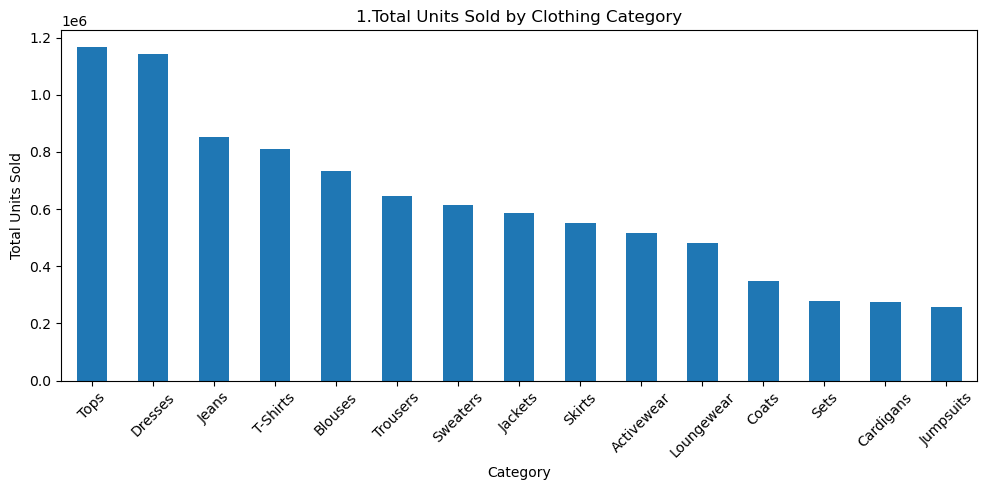

In [63]:
tmp = df.groupby("category")["units_sold"].sum().sort_values(ascending=False)
tmp.plot(kind="bar", figsize=(10,5))
plt.title("1.Total Units Sold by Clothing Category")
plt.xlabel("Category")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*****Tops and Dresses have the highest total units sold among the categories.******

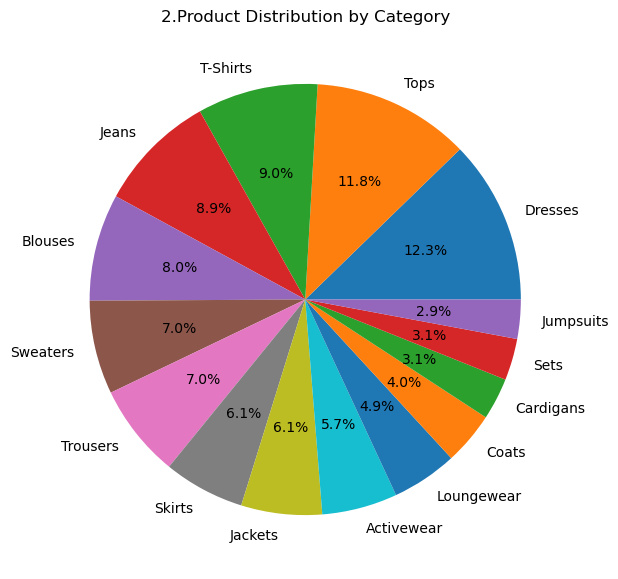

In [61]:
tmp = df["category"].value_counts()
plt.figure(figsize=(7,7))
plt.pie(tmp.values, labels=tmp.index, autopct="%1.1f%%")
plt.title("2.Product Distribution by Category")
plt.show()

******The product mix is spread across 15 categories; Dresses and Tops are the largest groups by record count.*****

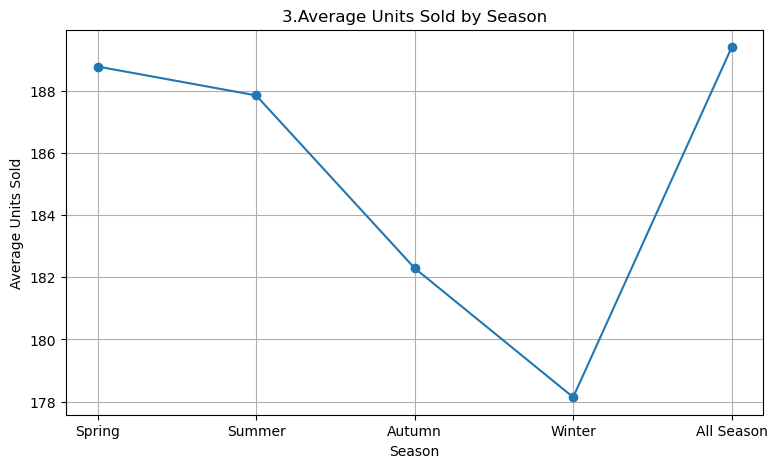

In [60]:
season_order = ["Spring", "Summer", "Autumn", "Winter", "All Season"]
tmp = df.groupby("season", observed=True)["units_sold"].mean().reindex(season_order)
plt.figure(figsize=(9,5))
plt.plot(tmp.index, tmp.values, marker="o")
plt.title("3.Average Units Sold by Season")
plt.xlabel("Season")
plt.ylabel("Average Units Sold")
plt.grid(True)
plt.show()

*****Spring shows the highest average sales among the listed seasons in this dataset.*****

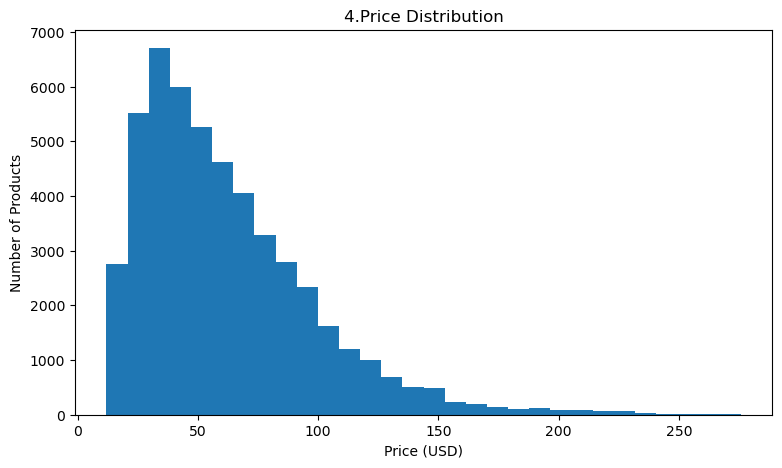

In [59]:
plt.figure(figsize=(9,5))
plt.hist(df["price_usd"], bins=30)
plt.title("4.Price Distribution")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Products")
plt.show()

*****Prices are concentrated toward the lower-to-middle range, with a smaller number of higher-priced products.*****

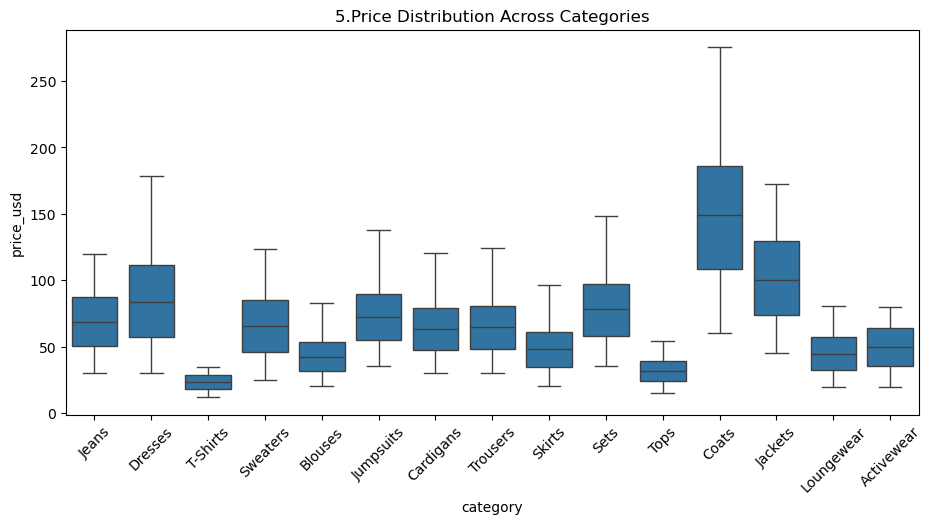

In [58]:
plt.figure(figsize=(11,5))
sns.boxplot(data=df, x="category", y="price_usd")
plt.title("5.Price Distribution Across Categories")
plt.xticks(rotation=45)
plt.show()

*****Price levels vary substantially across clothing categories; higher-priced categories show wider distributions.****

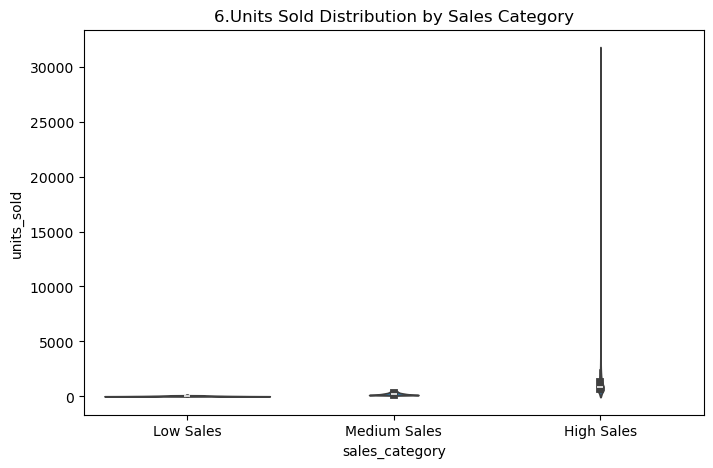

In [57]:
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="sales_category", y="units_sold")
plt.title("6.Units Sold Distribution by Sales Category")
plt.show()


*****The violin plot shows the distribution of sales across the defined low, medium and high sales groups.****

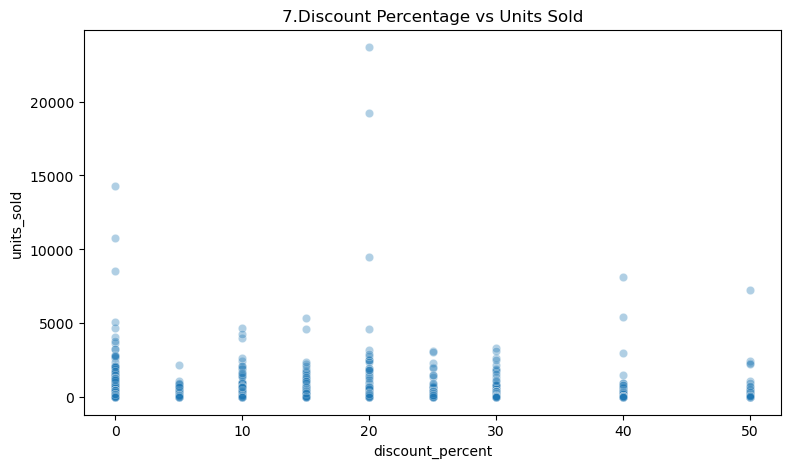

In [56]:
sample_df = df.sample(min(5000, len(df)), random_state=42)
plt.figure(figsize=(9,5))
sns.scatterplot(data=sample_df, x="discount_percent", y="units_sold", alpha=0.35)
plt.title("7.Discount Percentage vs Units Sold")
plt.show()


*****Discount percentage has only a weak positive relationship with units sold; discount alone does not explain most sales variation.*****

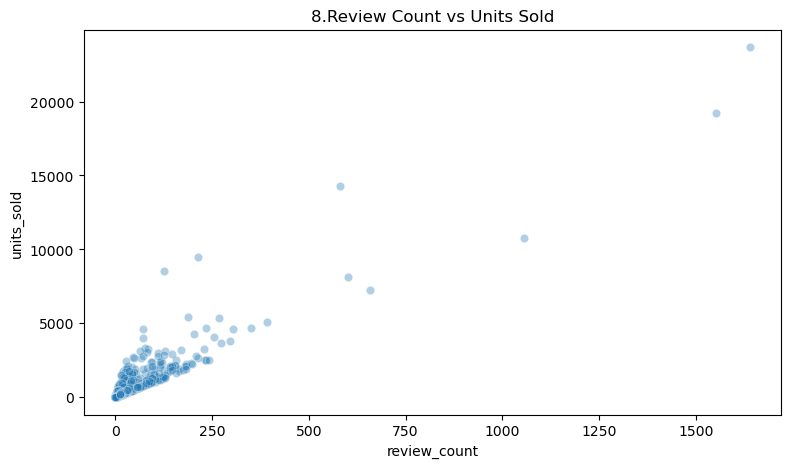

In [55]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=sample_df, x="review_count", y="units_sold", alpha=0.35)
plt.title("8.Review Count vs Units Sold")
plt.show()


****Review count has a strong positive association with units sold; this is correlation, not proof of causation.****


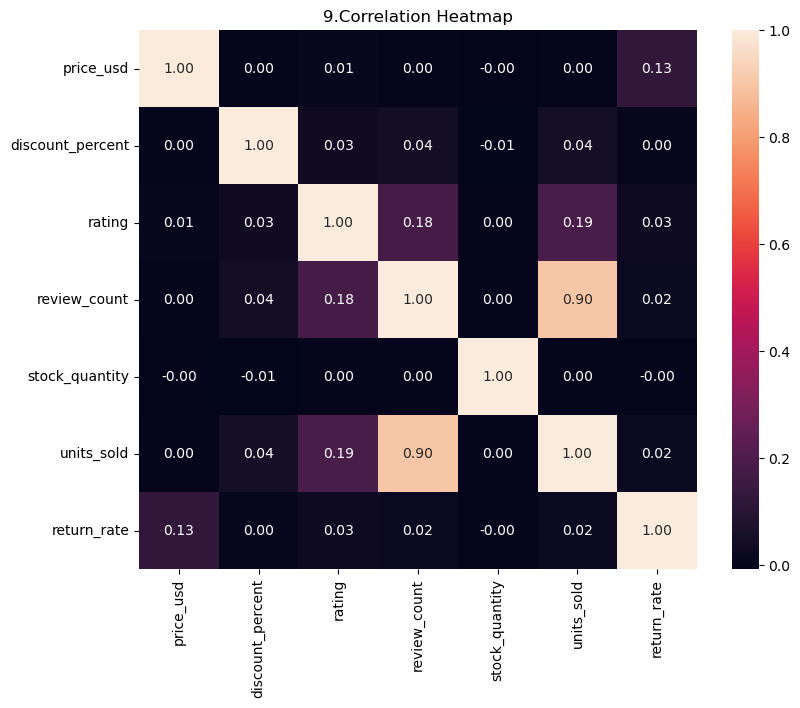

In [54]:
corr = df[[
    "price_usd", "discount_percent", "rating",
    "review_count", "stock_quantity", "units_sold",
    "return_rate"
]].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("9.Correlation Heatmap")
plt.show()

****The heatmap shows review_count has the strongest simple correlation with units_sold among the numeric variables shown.****

****Cotton is the highest-volume material by total units sold.****

# CHART 11 - Style bar chart

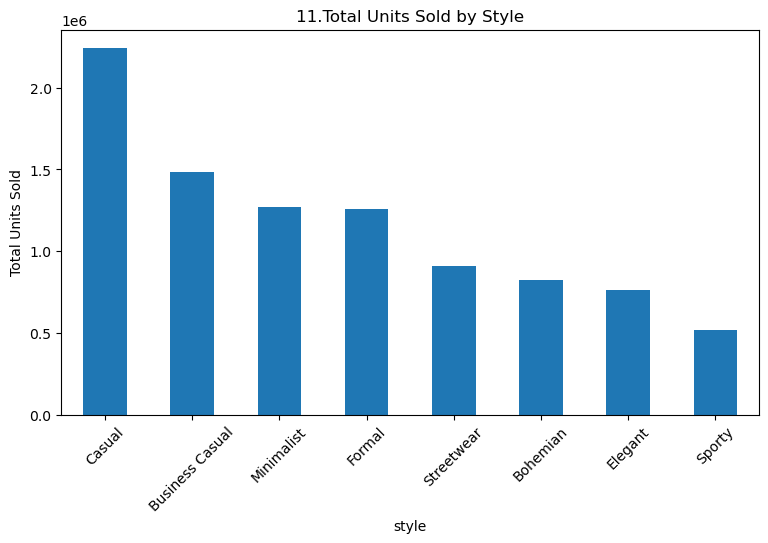

In [52]:
tmp = df.groupby("style")["units_sold"].sum().sort_values(ascending=False)
tmp.plot(kind="bar", figsize=(9,5))
plt.title("11.Total Units Sold by Style")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=45)
plt.show()

****Casual is the highest-volume style by total units sold.****

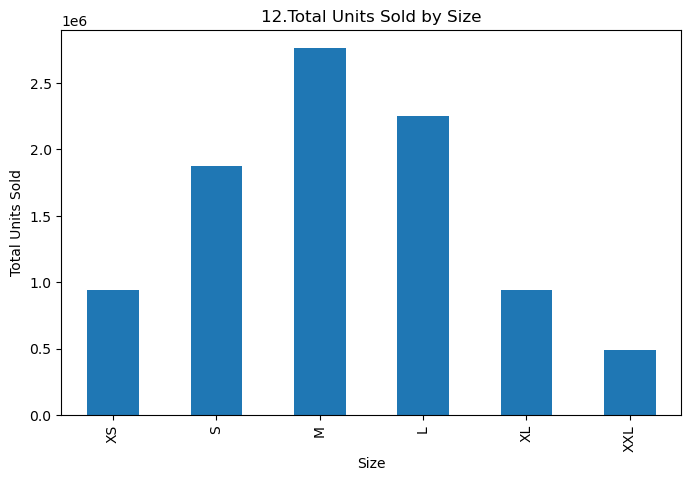

In [51]:
tmp = df.groupby("size")["units_sold"].sum().reindex(["XS","S","M","L","XL","XXL"])
tmp.plot(kind="bar", figsize=(8,5))
plt.title("12.Total Units Sold by Size")
plt.xlabel("Size")
plt.ylabel("Total Units Sold")
plt.show()


****M is the highest-volume size, followed by L.****

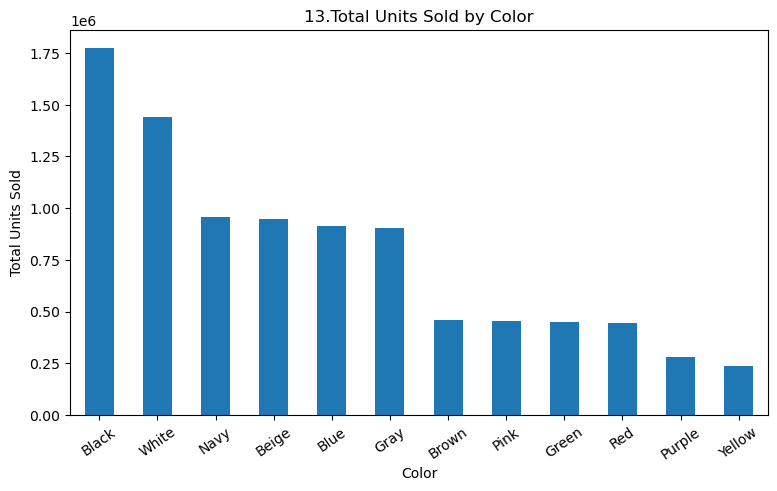

In [50]:
tmp = df.groupby("color")["units_sold"].sum().sort_values(ascending=False)
tmp.plot(kind="bar", figsize=(9,5))
plt.title("13.Total Units Sold by Color")
plt.xlabel("Color")
plt.ylabel("Total Units Sold")
plt.xticks(rotation=35)
plt.show()


****Black is the highest-volume color by total units sold.****

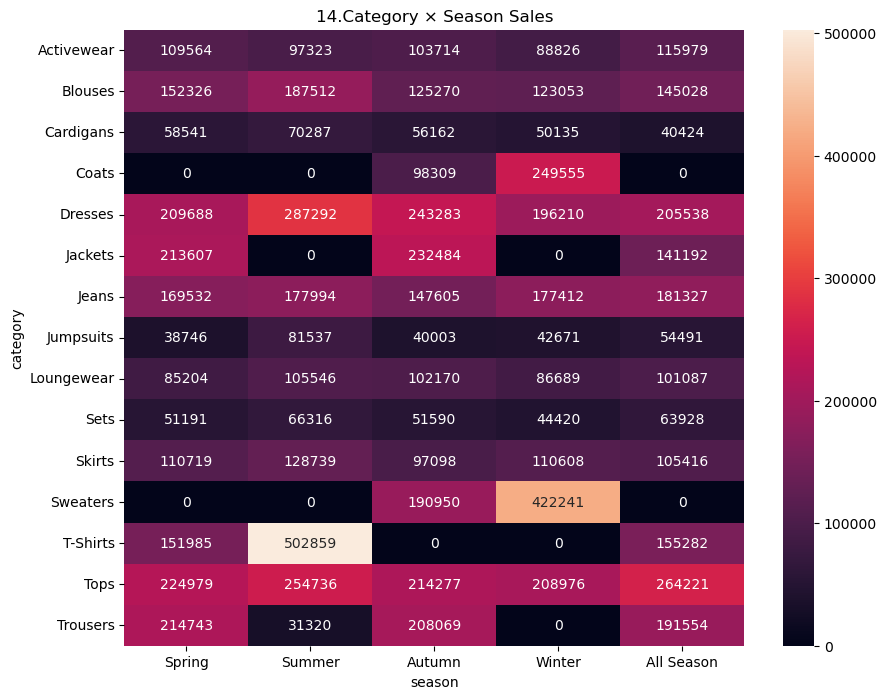

In [49]:
pivot = pd.pivot_table(
    df,
    values="units_sold",
    index="category",
    columns="season",
    aggfunc="sum",
    fill_value=0
)
pivot = pivot[season_order]

plt.figure(figsize=(10,8))
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("14.Category × Season Sales")
plt.show()


****The category × season heatmap helps identify which category-season combinations contribute the most sales.****

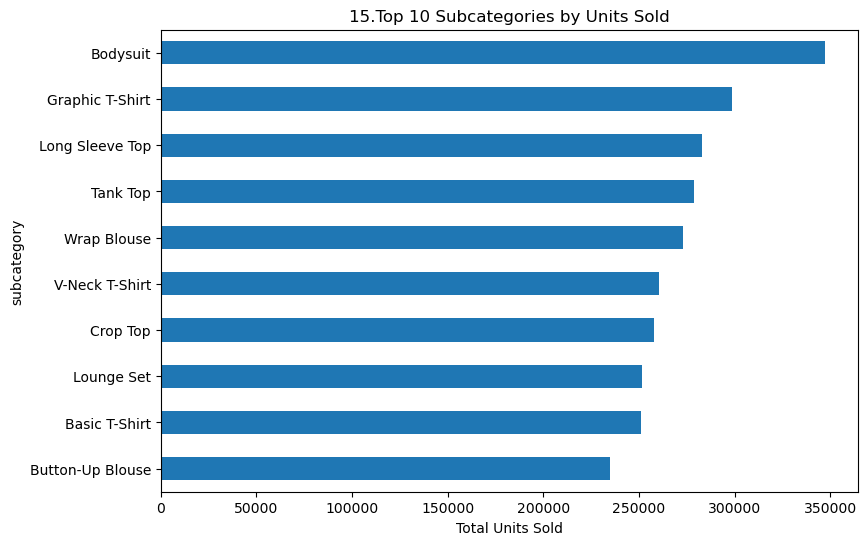

In [48]:
tmp = df.groupby("subcategory")["units_sold"].sum().sort_values(ascending=False).head(10)
tmp.sort_values().plot(kind="barh", figsize=(9,6))
plt.title("15.Top 10 Subcategories by Units Sold")
plt.xlabel("Total Units Sold")
plt.show()

****Bodysuit is the highest-selling subcategory in this dataset.****

####Correlation values####

In [65]:
print("\nCorrelation with Units Sold:")
print(df[[
    "price_usd", "discount_percent", "rating",
    "review_count", "stock_quantity", "return_rate",
    "units_sold"
]].corr()["units_sold"].sort_values(ascending=False))


Correlation with Units Sold:
units_sold          1.000000
review_count        0.901413
rating              0.188214
discount_percent    0.044819
return_rate         0.022652
price_usd           0.001751
stock_quantity      0.001024
Name: units_sold, dtype: float64


In [66]:
print("\nSales by Category:")
print(df.groupby("category")["units_sold"].sum().sort_values(ascending=False))

print("\nSales by Season:")
print(df.groupby("season")["units_sold"].sum().sort_values(ascending=False))

print("\nSales by Material:")
print(df.groupby("material")["units_sold"].sum().sort_values(ascending=False))



Sales by Category:
category
Tops          1167189
Dresses       1142011
Jeans          853870
T-Shirts       810126
Blouses        733189
Trousers       645686
Sweaters       613191
Jackets        587283
Skirts         552580
Activewear     515406
Loungewear     480696
Coats          347864
Sets           277445
Cardigans      275549
Jumpsuits      257448
Name: units_sold, dtype: int64

Sales by Season:
season
Summer        1991461
Autumn        1910984
Winter        1800796
Spring        1790825
All Season    1765467
Name: units_sold, dtype: int64

Sales by Material:
material
Cotton             2766898
Cotton Blend       1518130
Polyester          1238405
Denim              1039784
Polyester Blend     697007
Viscose             625887
Wool                574596
Linen               411971
Nylon               211059
Leather             175796
Name: units_sold, dtype: int64


**** 5.Insight Generation and Report ****

INSIGHTS

CONCLUSION

The analysis shows clear differences in sales across categories, materials, styles, sizes, colors and seasons.
Tops, Dresses, Cotton, Casual style and size M are among the strongest volume segments in this dataset.
Review count has a strong association with units sold, while discount percentage shows only a weak association.
